In [1]:
import json 
import requests
import keras 
import  matplotlib.pyplot as plt
plt.style.use('dark_background')
import numpy as np
import pandas as pd 
import seaborn as sns 
from sklearn.metrics import mean_absolute_error

In [2]:
response = requests.get('https://min-api.cryptocompare.com/data/histoday?fsym=ETH&tsym=CAD&limit=1000')
df = pd.DataFrame(json.loads(response.content)['Data'])
df.head()

,time,high,low,open,volumefrom,volumeto,close,conversionType,conversionSymbol
0,1650326400,3929.90,3890.74,3841.71,124016.21,4.841983e+08,3904.31,multiply,BTC
1,1650412800,3879.09,3833.09,3904.31,127695.41,4.909861e+08,3844.98,multiply,BTC
2,1650499200,3792.71,3736.14,3844.98,160787.74,6.038395e+08,3755.51,multiply,BTC
3,1650585600,3795.10,3720.39,3755.51,124511.04,4.688859e+08,3765.82,multiply,BTC
4,1650672000,3772.89,3733.11,3765.82,71212.55,2.667407e+08,3745.70,multiply,BTC


In [3]:
df = df.set_index('time')
df.head()

,high,low,open,volumefrom,volumeto,close,conversionType,conversionSymbol
time,,,,,,,,
1650326400,3929.90,3890.74,3841.71,124016.21,4.841983e+08,3904.31,multiply,BTC
1650412800,3879.09,3833.09,3904.31,127695.41,4.909861e+08,3844.98,multiply,BTC
1650499200,3792.71,3736.14,3844.98,160787.74,6.038395e+08,3755.51,multiply,BTC
1650585600,3795.10,3720.39,3755.51,124511.04,4.688859e+08,3765.82,multiply,BTC
1650672000,3772.89,3733.11,3765.82,71212.55,2.667407e+08,3745.70,multiply,BTC


In [4]:
df = df[['high', 'low', 'open', 'volumefrom', 'volumeto', 'close']]
df.head()

,high,low,open,volumefrom,volumeto,close
time,,,,,,
1650326400,3929.90,3890.74,3841.71,124016.21,4.841983e+08,3904.31
1650412800,3879.09,3833.09,3904.31,127695.41,4.909861e+08,3844.98
1650499200,3792.71,3736.14,3844.98,160787.74,6.038395e+08,3755.51
1650585600,3795.10,3720.39,3755.51,124511.04,4.688859e+08,3765.82
1650672000,3772.89,3733.11,3765.82,71212.55,2.667407e+08,3745.70


In [5]:
def train_test_split(df):
    split_row = len(df) - int(0.1 * len(df))
    train_data = df.iloc[:split_row]
    test_data = df.iloc[split_row:]
    return train_data, test_data
train, test = train_test_split(df)

In [6]:
len(test)

100

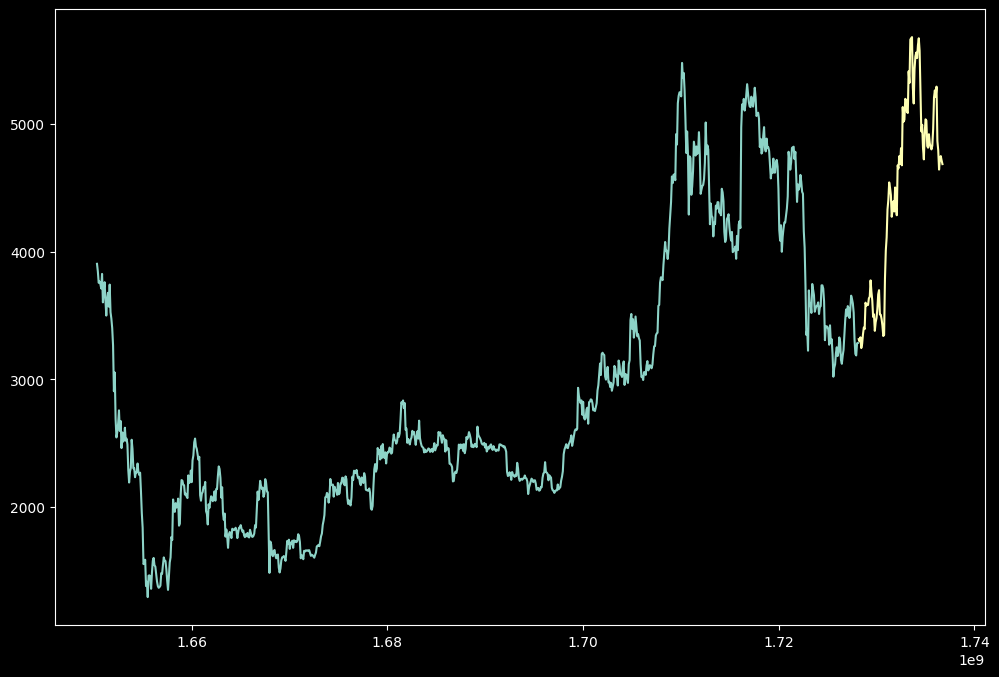

In [7]:
fig, ax = plt.subplots(1, figsize=(12, 8))
ax.plot(train['close'], label='train_data')
ax.plot(test['close'], label='test_data')

In [8]:
def norm_zero_base(df):
    return df / df.iloc[0] - 1

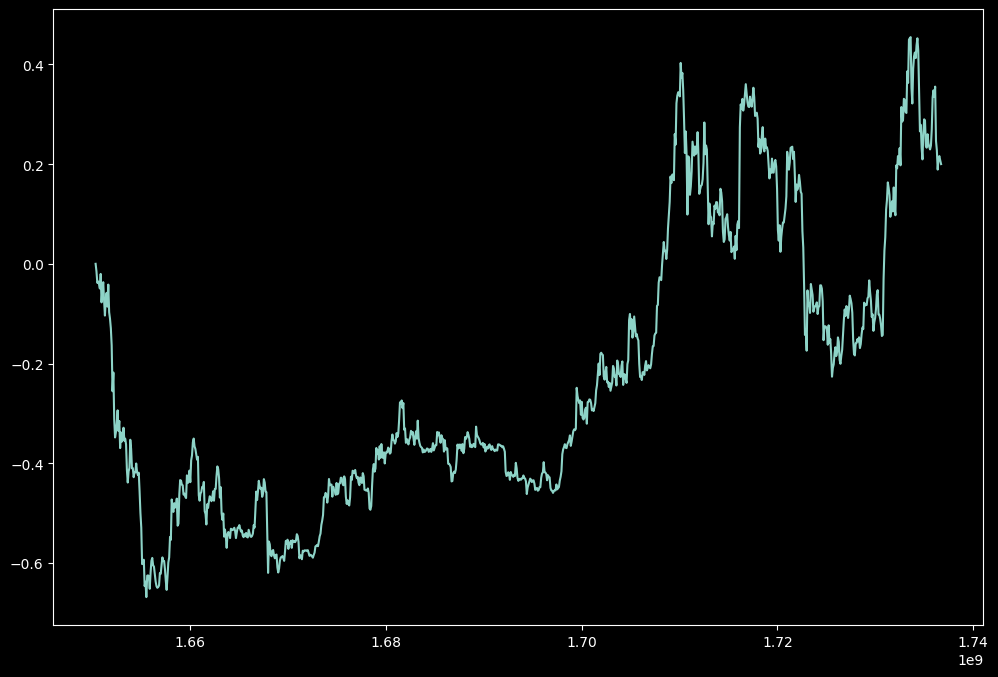

In [9]:
sample = norm_zero_base(df['close'])
fig, ax = plt.subplots(1, figsize=(12, 8))
ax.plot(sample, label='sample')

In [10]:
def norm_min_max(df):
    return (df - df.min()) / (df.max() - df.min())

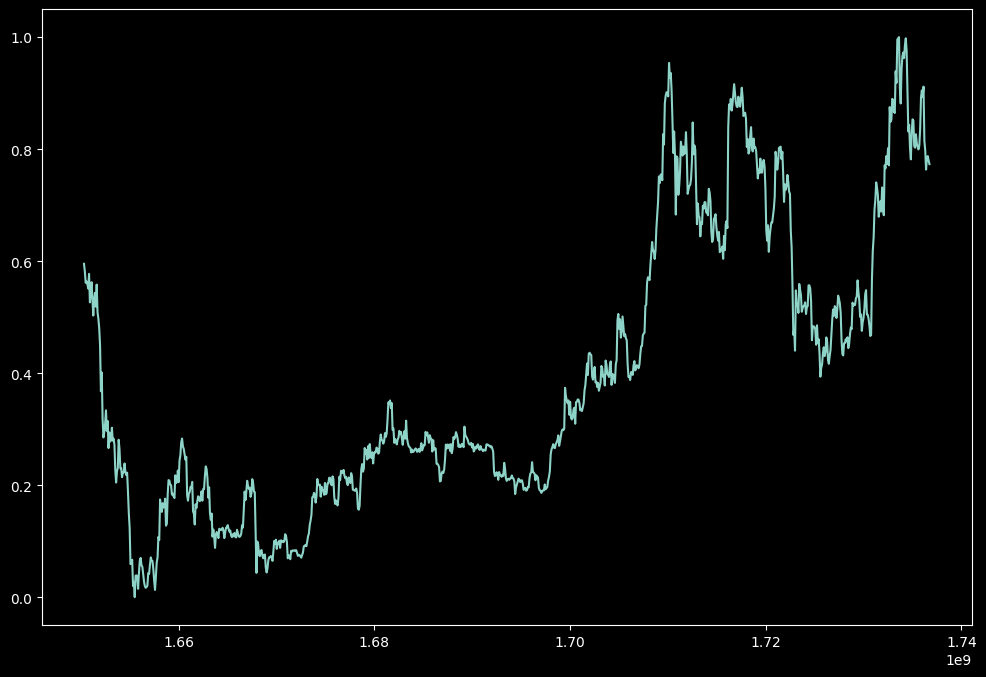

In [11]:
sample = norm_min_max(df['close'])
fig, ax = plt.subplots(1, figsize=(12, 8))
ax.plot(sample, label='sample')

In [12]:
def extract_windows_data(df):
    window_data = []
    for idx in range(len(df) - 10):
        tmp = df[idx: (idx + 10)].copy()
        tmp = norm_zero_base(tmp)
        window_data.append(tmp.values)
    return np.array(window_data)

In [13]:
def prepare_data(df):
    train_data, test_data = train_test_split(df)
    X_train = extract_windows_data(train_data)
    X_test = extract_windows_data(test_data)
    y_train = train_data['close'][10:].values
    y_test = test_data['close'][10:].values
    
    y_train = y_train / train_data['close'][:-10].values - 1
    y_test = y_test / test_data['close'][:-10].values - 1
    return train_data, test_data, X_train, X_test, y_train, y_test

In [14]:
train, test, X_train, X_test, y_train, y_test = prepare_data(df)

In [15]:
y_train

array([-7.32856766e-02, -9.00082705e-02, -3.39900573e-02, -2.35592779e-02,
       -4.71874416e-02,  8.21860963e-03, -7.83472544e-02, -3.53802720e-02,
       -8.12167789e-02, -1.31658166e-01, -1.96728742e-01, -1.27462917e-01,
       -2.58885404e-01, -3.08028066e-01, -2.75459169e-01, -2.90435350e-01,
       -2.18070833e-01, -2.53036111e-01, -2.13738662e-01, -2.46293636e-01,
       -1.11117610e-01, -1.77289284e-01, -5.93157930e-02,  2.98689304e-02,
       -2.57942263e-02, -4.51278768e-02, -9.68853613e-02, -1.17584509e-01,
       -1.80273966e-01, -7.42594775e-02, -1.07508235e-01,  5.84471686e-03,
       -2.98120339e-02, -1.21238719e-01, -8.51120418e-02, -1.19116087e-01,
       -8.72637152e-02, -8.33486146e-03,  6.79842474e-02, -2.17702362e-03,
       -2.39451097e-02, -1.01953411e-01, -1.34897994e-01, -1.51666486e-01,
       -2.02986020e-01, -3.04851508e-01, -3.11930926e-01, -3.01524684e-01,
       -4.10225734e-01, -3.77926260e-01, -4.25055988e-01, -3.55697776e-01,
       -3.10269129e-01, -

In [16]:
X_train[0]

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-1.29290822e-02, -1.48172327e-02,  1.62948270e-02,
         2.96670895e-02,  1.40186181e-02, -1.51960270e-02],
       [-3.49092852e-02, -3.97353717e-02,  8.51183457e-04,
         2.96505836e-01,  2.47091323e-01, -3.81117278e-02],
       [-3.43011273e-02, -4.37834448e-02, -2.24379248e-02,
         3.99004291e-03, -3.16243354e-02, -3.54710563e-02],
       [-3.99526706e-02, -4.05141438e-02, -1.97542240e-02,
        -4.25780307e-01, -4.49108583e-01, -4.06243357e-02],
       [-4.70037406e-02, -4.72043879e-02, -2.49914752e-02,
        -3.89601892e-01, -4.19809862e-01, -4.94888982e-02],
       [-1.84075931e-02, -3.62912968e-02, -3.40004842e-02,
         1.39007699e+00,  1.34161630e+00, -2.02750294e-02],
       [-6.90653706e-02, -7.92882588e-02, -4.31058044e-03,
         3.58858411e-01,  2.53740936e-01, -7.73555379e-02],
       [-4.77340390e-02, -5.40385634e-02, -6.232

In [17]:
model = keras.models.Sequential()
model.add(keras.layers.LSTM(100, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(units=1))
model.add(keras.layers.Activation('relu'))

model.compile(loss='mse', optimizer='adam')

c:\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
history = model.fit(X_train, y_train, epochs=200, batch_size=32, shuffle=True, verbose=1)

Epoch 1/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0157
Epoch 2/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0116
Epoch 3/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0119
Epoch 4/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0111
Epoch 5/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0095
Epoch 6/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0097
Epoch 7/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0080
Epoch 8/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0068
Epoch 9/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0076
Epoch 10/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0078
Epoch 11/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0079
Epoch 12/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0069
Epoch 13/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0066
Epoch 14/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0076
Epoch 15/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - lo

In [19]:
targets = test['close'][10:]
preds = model.predict(X_test).squeeze()
mean_absolute_error(preds, y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 185ms/step


0.03762441808950429

In [20]:
preds

array([0.08107096, 0.08607677, 0.07869279, 0.11209004, 0.10802777,
       0.10728814, 0.08374909, 0.06222491, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.01396611, 0.        , 0.        , 0.        , 0.00445962,
       0.        , 0.        , 0.06711032, 0.08009776, 0.10605921,
       0.20908795, 0.23849018, 0.26406586, 0.28317988, 0.30779824,
       0.28632843, 0.12801225, 0.0854387 , 0.04699917, 0.02578184,
       0.        , 0.        , 0.02792224, 0.04753312, 0.10891357,
       0.0834071 , 0.07622883, 0.07587254, 0.12170856, 0.15117577,
       0.16706705, 0.08749148, 0.10446769, 0.06765486, 0.07661919,
       0.12270465, 0.13761649, 0.10441942, 0.12762609, 0.11825107,
       0.01408559, 0.        , 0.04367534, 0.08096394, 0.03998019,
       0.0386347 , 0.        , 0.003163  , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [21]:
targets[:10] * (preds[:10] + 1)

time
1729036800    3874.147299
1729123200    3889.979325
1729209600    3920.670763
1729296000    4055.024857
1729382400    4182.361794
1729468800    4080.478532
1729555200    3920.310485
1729641600    3705.220907
1729728000    3509.060000
1729814400    3379.400000
Name: close, dtype: float64

In [22]:
len(train[-10:]) * (preds[:10] + 1)

array([10.810709, 10.860767, 10.786928, 11.1209  , 11.080278, 11.072882,
       10.83749 , 10.622249, 10.      , 10.      ], dtype=float32)

In [23]:
len(preds)

90

In [24]:
preds

array([0.08107096, 0.08607677, 0.07869279, 0.11209004, 0.10802777,
       0.10728814, 0.08374909, 0.06222491, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.01396611, 0.        , 0.        , 0.        , 0.00445962,
       0.        , 0.        , 0.06711032, 0.08009776, 0.10605921,
       0.20908795, 0.23849018, 0.26406586, 0.28317988, 0.30779824,
       0.28632843, 0.12801225, 0.0854387 , 0.04699917, 0.02578184,
       0.        , 0.        , 0.02792224, 0.04753312, 0.10891357,
       0.0834071 , 0.07622883, 0.07587254, 0.12170856, 0.15117577,
       0.16706705, 0.08749148, 0.10446769, 0.06765486, 0.07661919,
       0.12270465, 0.13761649, 0.10441942, 0.12762609, 0.11825107,
       0.01408559, 0.        , 0.04367534, 0.08096394, 0.03998019,
       0.0386347 , 0.        , 0.003163  , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

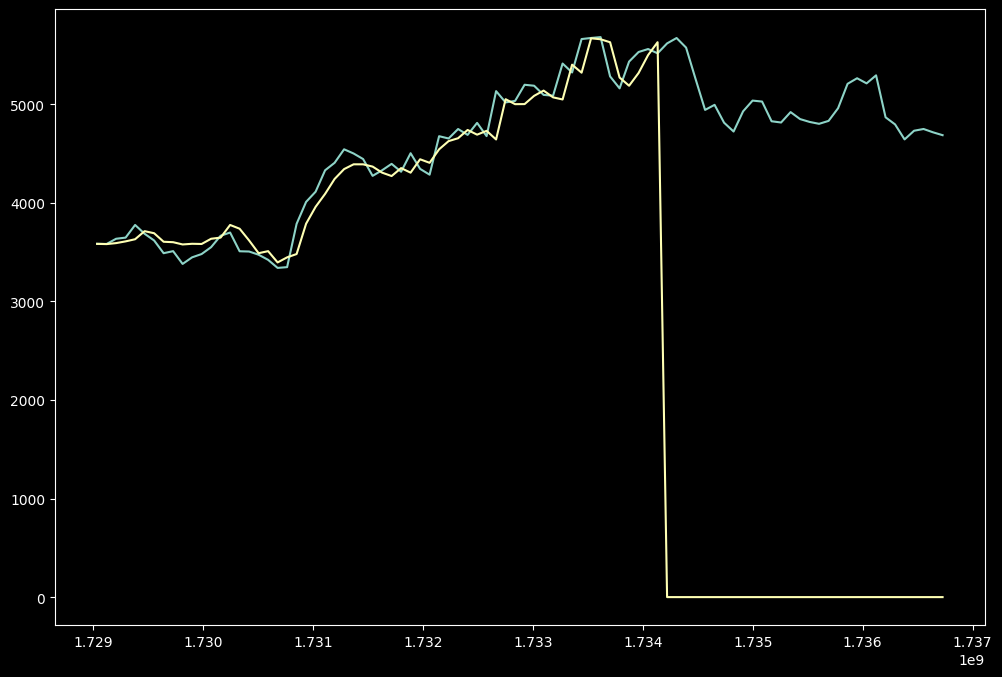

In [25]:
preds_plt = preds.copy()
preds_plt[:60] = test['close'].iloc[:60].values * (preds_plt[:60] + 1)
preds_plt = pd.Series(index=targets.index, data=preds_plt)
fig, ax = plt.subplots(1, figsize=(12, 8))
ax.plot(targets, label='target')
ax.plot(preds_plt, label='predics')